In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv(r'c:\Users\Amey\Downloads\archive (10)\diamonds.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


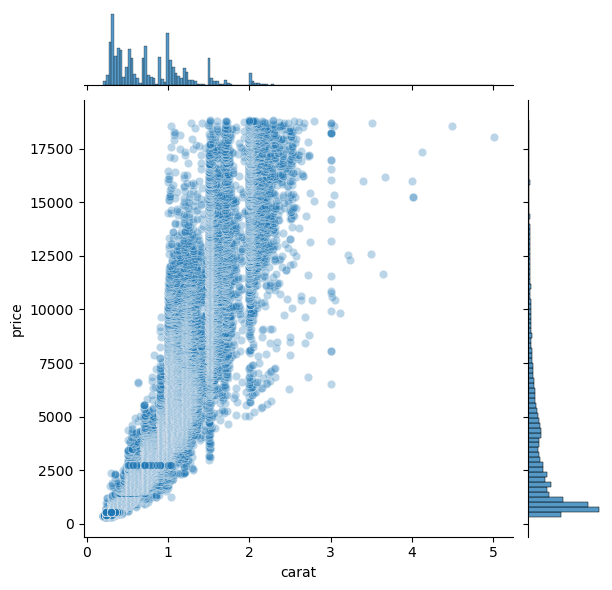

In [5]:
sns.jointplot(x='carat', y='price', data= df, alpha=0.3)

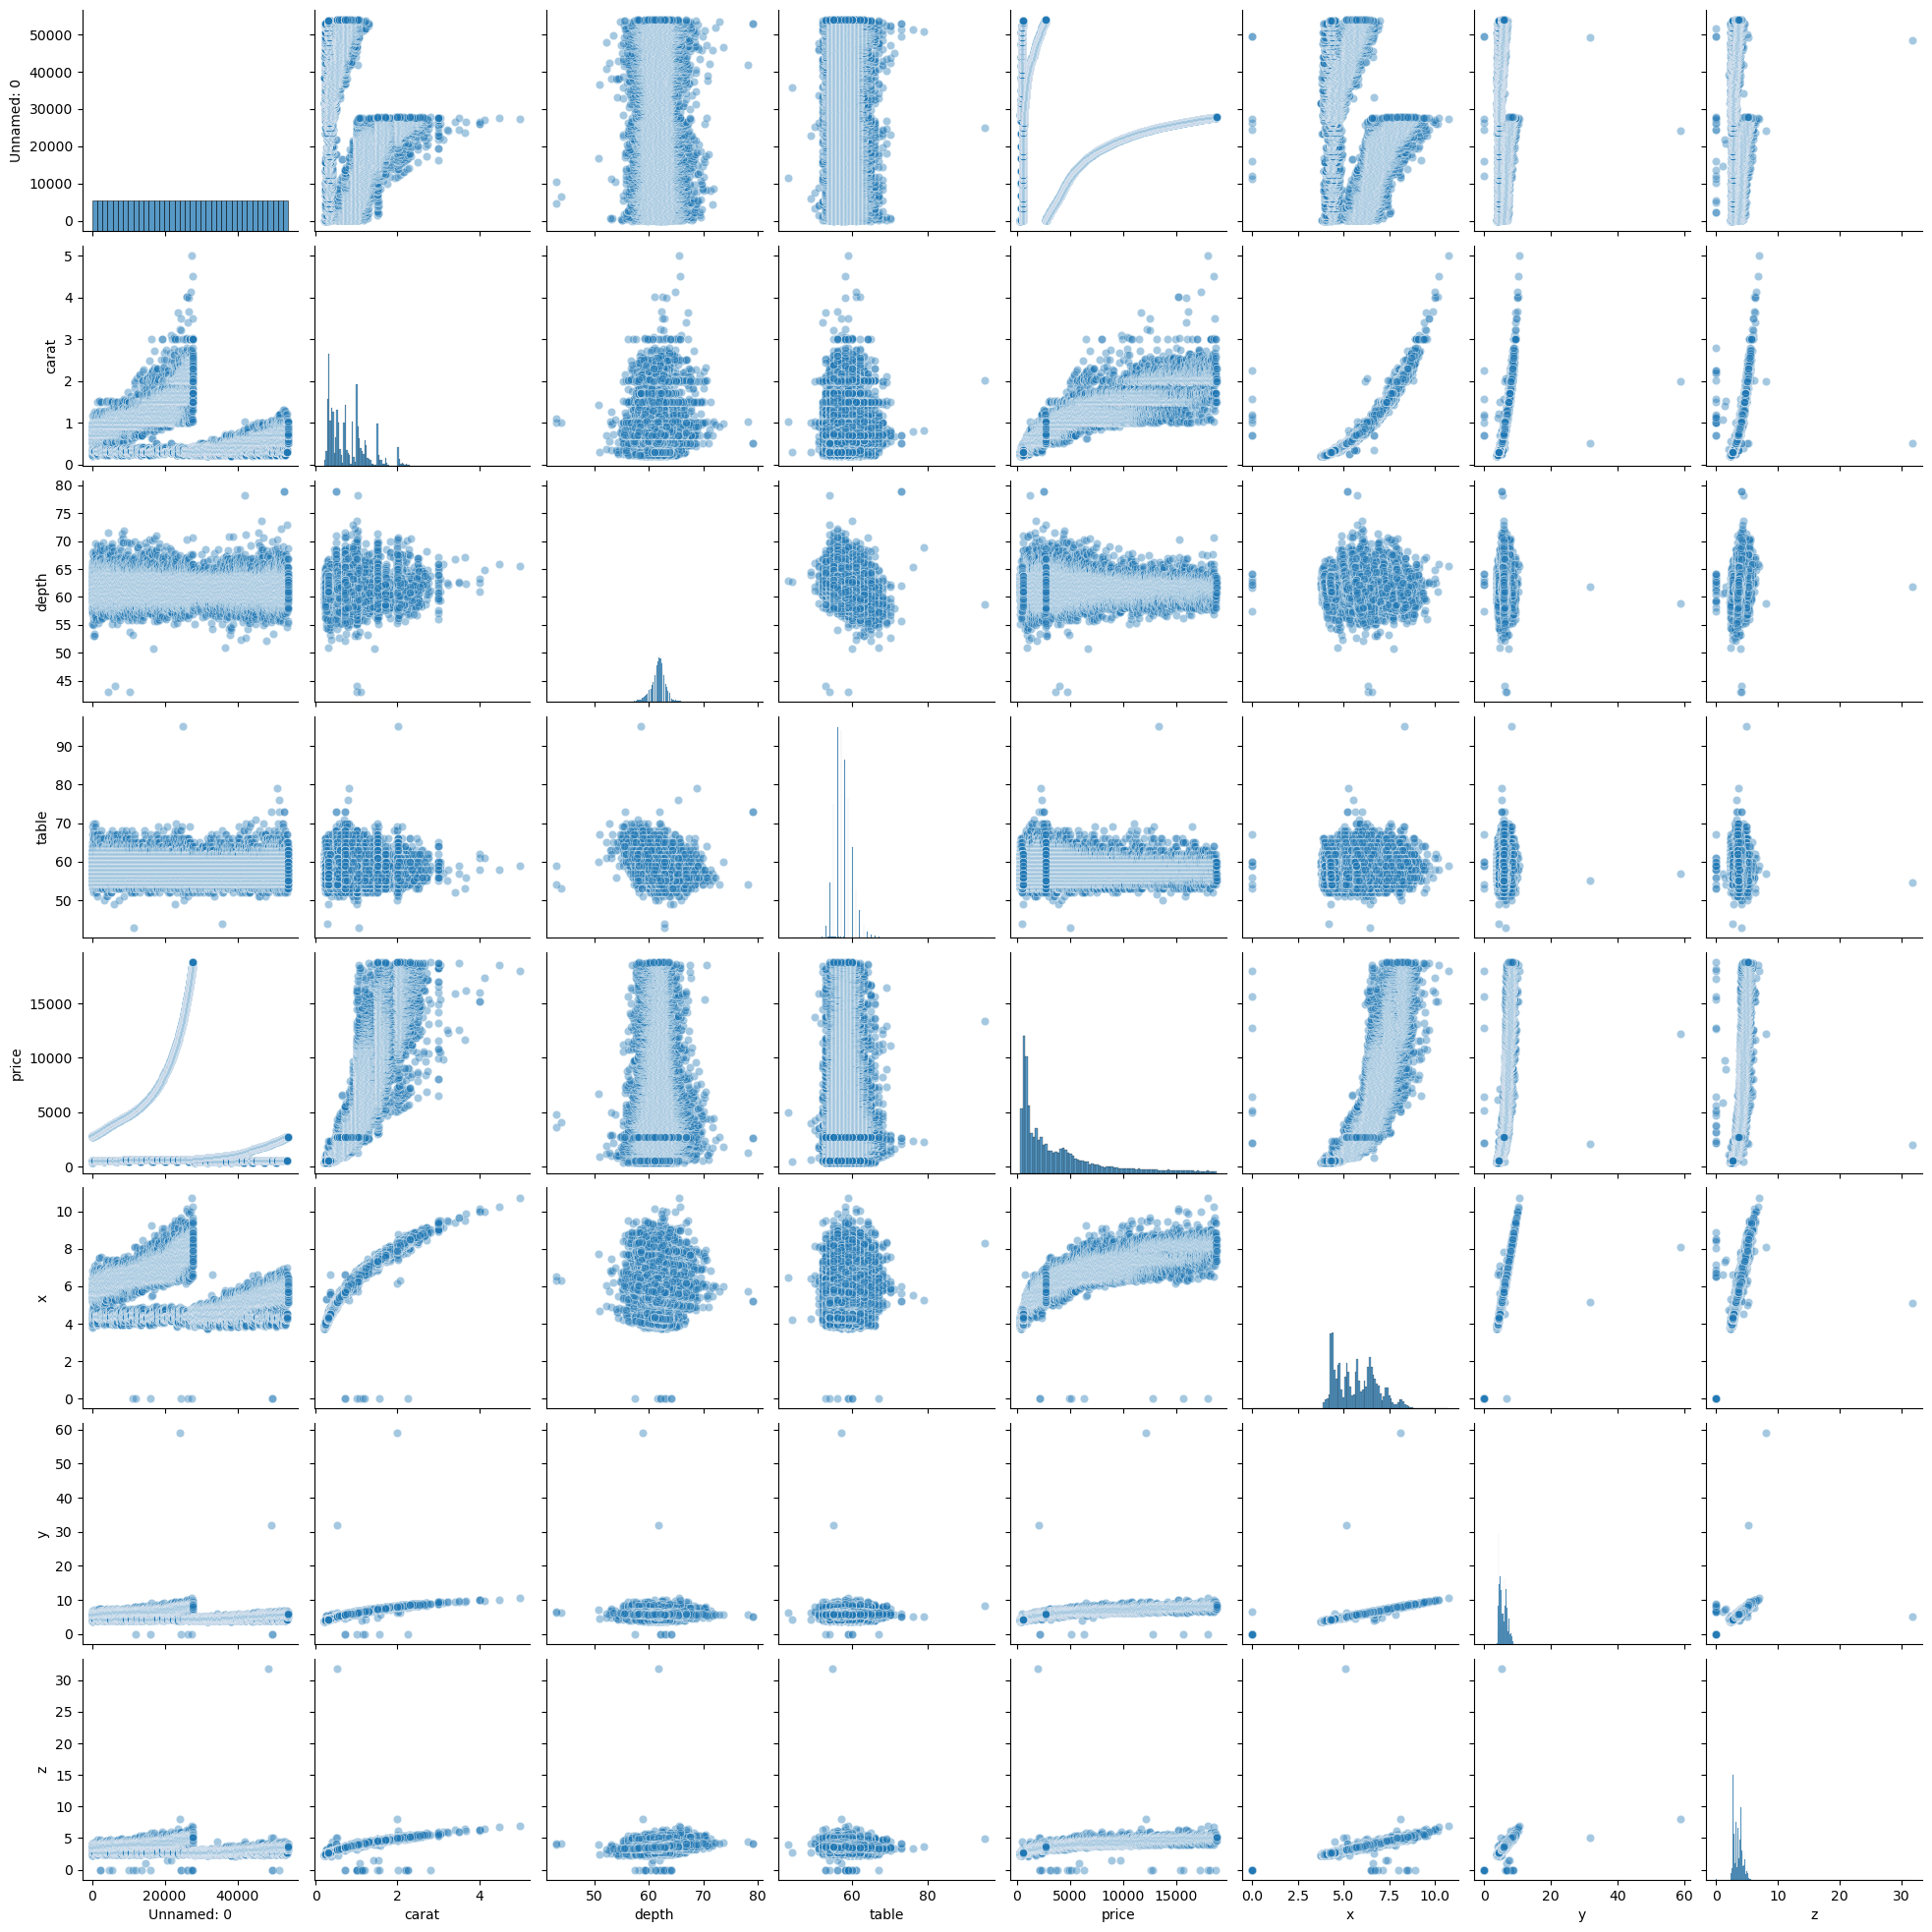

In [6]:
sns.pairplot(df,kind='scatter',plot_kws={'alpha':0.4
                                         })

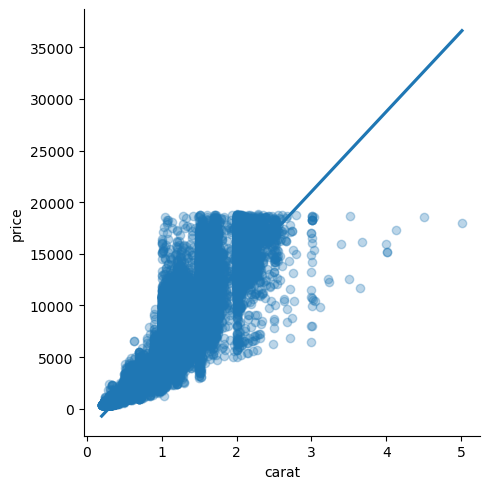

In [7]:
sns.lmplot(
    x='carat',
    y='price',
    data=df,
    scatter_kws={'alpha':0.3}

)

In [8]:
from sklearn.model_selection import train_test_split


In [23]:
X = df[['carat','depth','table','x','y']]
y = df['price']

In [24]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:



print(X.shape)
print(y.shape)

(53940, 5)
(53940,)


In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
lm = LinearRegression()

In [28]:
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:

lm.coef_

array([10683.35451383,  -200.95985642,  -104.32914428, -1258.18250707,
          41.68671112])

In [32]:
cdf = pd.DataFrame(lm.coef_,X.columns,columns=['Coef'])
cdf

,Coef
carat,10683.354514
depth,-200.959856
table,-104.329144
x,-1258.182507
y,41.686711


In [33]:
prediction = lm.predict(X_test

                        )

In [34]:
prediction

array([ 201.52228019, 2361.21621348, 1052.07213233, ...,  600.72826781,
       7400.30849987, 5691.24815229], shape=(10788,))

Text(0.5, 1.0, 'Evaluation of our LM model')

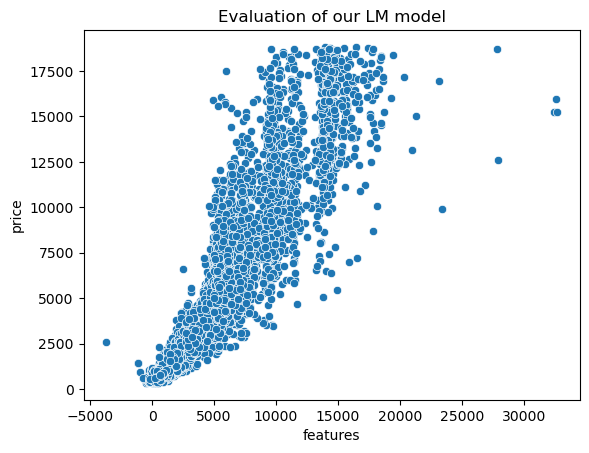

In [36]:
sns.scatterplot(x=prediction,y = y_test )
plt.xlabel("features")
plt.title("Evaluation of our LM model")

In [37]:
from sklearn.metrics import mean_squared_error , mean_absolute_error
import math

In [38]:
print("Mean Absolute Error:" , mean_absolute_error(y_test, prediction))               
print("Mean squared Error:" , mean_squared_error(y_test, prediction) )
print("RMSE:" , math.sqrt(mean_squared_error(y_test, prediction)))

Mean Absolute Error: 888.3497372019617
Mean squared Error: 2242051.61430373
RMSE: 1497.3481940763577


In [39]:
residuals = y_test - prediction
residuals

1388      357.477720
50052    -160.216213
41645     185.927868
42377      73.893902
17244   -3134.444783
            ...     
44081     111.209133
23713     426.229922
31375     160.271732
21772    2435.691500
4998    -1949.248152
Name: price, Length: 10788, dtype: float64

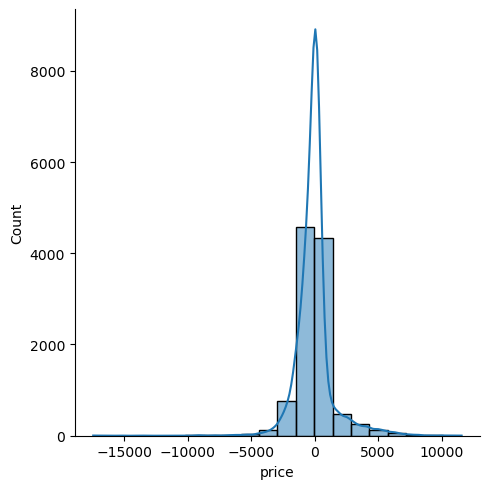

In [40]:
sns.displot(residuals , bins = 20 , kde = True)


<function matplotlib.pyplot.show(close=None, block=None)>

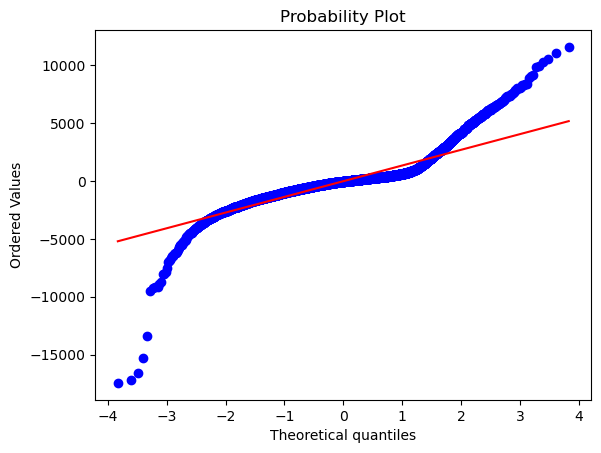

In [41]:
import pylab
import scipy.stats as stats

stats.probplot(
    residuals,
    dist="norm",
    plot=pylab
)
pylab.show